# Denoising of Gamillus Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

from careamics.config import create_n2v_configuration
from careamics.config.data import NGDataConfig
from careamics.config.configuration_factories import _create_ng_data_configuration
from careamics.config.inference_model import InferenceConfig
from careamics.dataset_ng.dataset import Mode
from careamics.dataset_ng.factory import create_dataset
from careamics.dataset_ng.legacy_interoperability import imageregions_to_tileinfos
from careamics.dataset_ng.patch_extractor.patch_extractor_factory import create_czi_extractor
from careamics.lightning.dataset_ng.data_module import CareamicsDataModule
from careamics.lightning.dataset_ng.lightning_modules import N2VModule
from careamics.prediction_utils import convert_outputs

/localscratch/mamba/envs/cmcs/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from pathlib import Path

data_dir = Path("/home/igor.zubarev/data/zeiss_test")
exp_base_dir = Path("/home/igor.zubarev/projects/careamics/experiments")


In [3]:
image_path = data_dir / "test-gamillus-3-pos-0,3%LP-AB1-raw-T1-10_chan2.czi"

## Train 2-D Model

In [ ]:
exp_dir = exp_base_dir / "n2v2_2d_2ep"

config = create_n2v_configuration(
    experiment_name="CustomerData_n2v2",
    data_type="czi",
    axes="SCYX",
    patch_size=[64, 64],
    batch_size=32,
    num_epochs=1,
    independent_channels=True,
    n_channels=1,
    use_n2v2=True,
    roi_size=11,
    masked_pixel_percentage=0.2,
    model_params={"use_batch_norm": False},
    optimizer_params={"lr": 1e-3},
    train_dataloader_params={"num_workers": 0},
    val_dataloader_params={"num_workers": 0},
    logger="tensorboard",
)

ng_data_config = _create_ng_data_configuration(
    data_type="custom",
    axes=config.data_config.axes,
    patch_size=config.data_config.patch_size,
    batch_size=config.data_config.batch_size,
    augmentations=list(config.data_config.transforms),
    patch_overlaps=None,
    train_dataloader_params=config.data_config.train_dataloader_params,
    val_dataloader_params=config.data_config.val_dataloader_params,
)

data_module = CareamicsDataModule(
    data_config=ng_data_config,
    train_data=[image_path],
    val_data=[image_path],
    pred_data=[image_path],
    image_stack_loader=lambda source, axes: create_czi_extractor(source, axes).image_stacks,
)

In [6]:
ng_data_config.image_means = [100.290825]
ng_data_config.image_stds = [6.0161868]


ValidationError: 1 validation errors for NGDataConfig:

  Value error, Mean and std must be either both None, or both specified. [input=NGDataConfig(data_type='custom', axes='SCYX', patching=RandomPatchingModel(name='random', patch_size=[64, 64]), batch_size=32, image_means=[100.290825], image_stds=None, target_means=None, target_stds=None, transforms=[XYFlipModel(name='XYFlip', flip_x=True, flip_y=True, p=0.5, seed=None), XYRandomRotate90Model(name='XYRandomRotate90', p=0.5, seed=None)], train_dataloader_params={'num_workers': 0, 'shuffle': True, 'pin_memory': True}, val_dataloader_params={'num_workers': 0, 'pin_memory': True}, test_dataloader_params={}, seed=None)]

In [16]:
model = N2VModule(config.algorithm_config)

In [6]:
checkpoint = torch.load("/home/igor.zubarev/projects/careamics/experiments/n2v2_2d_2ep/checkpoints/epoch=1-step=12776.ckpt")

model.load_state_dict(checkpoint["state_dict"])

model.eval()



N2VModule(
  (model): UNet(
    (encoder): UnetEncoder(
      (pooling): MaxBlurPool()
      (encoder_blocks): ModuleList(
        (0): Conv_Block(
          (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (batch_norm1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (batch_norm2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (activation): ReLU()
        )
        (1): MaxBlurPool()
        (2): Conv_Block(
          (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (batch_norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (batch_norm2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


In [7]:
data_module.setup("fit")

Computing statistics:   0%|          | 398/817600 [00:00<10:16, 1325.57it/s]

Computing statistics: 100%|██████████| 817600/817600 [09:35<00:00, 1420.81it/s]


In [17]:
callbacks = [
    ModelCheckpoint(
        dirpath=exp_dir / "checkpoints",
        save_last=True,
        monitor="val_loss",
        mode="min",
        save_top_k=-1,
    ),
    LearningRateMonitor(logging_interval="step"),
]

trainer = Trainer(
    max_epochs=config.training_config.num_epochs,
    default_root_dir=exp_dir,
    callbacks=callbacks,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [18]:
trainer.fit(model, data_module)

Computing statistics: 100%|██████████| 817600/817600 [11:02<00:00, 1233.64it/s]
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type             | Params
---------------------------------------------
0 | model   | UNet             | 324 K 
1 | metrics | MetricCollection | 0     
---------------------------------------------
324 K     Trainable params
0         Non-trainable params
324 K     Total params
1.298     Total estimated model params size (MB)


/localscratch/mamba/envs/cmcs/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
/localscratch/mamba/envs/cmcs/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 0: 100%|██████████| 25550/25550 [19:06<00:00, 22.29it/s, v_num=14, train_loss_step=1.200]

/localscratch/mamba/envs/cmcs/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py:54: Detected KeyboardInterrupt, attempting graceful shutdown...


In [19]:
data_module.train_dataset.input_stats.means, data_module.train_dataset.input_stats.stds

(array([100.290825], dtype=float32), array([6.0161868]))

### Inference

In [20]:
inference_config = NGDataConfig(
    data_type="custom",
    patching={
        "name": "tiled",
        "patch_size": [128, 1024],
        "overlaps": [32, 32],
    },
    axes="YX",
    batch_size=1,
    image_means=data_module.train_dataset.input_stats.means,
    image_stds=data_module.train_dataset.input_stats.stds,
)

inf_data_module = CareamicsDataModule(
    data_config=inference_config,
    pred_data=[image_path],
    image_stack_loader=lambda source, axes: create_czi_extractor(source, axes).image_stacks,
)

In [21]:
predictions = trainer.predict(model, datamodule=inf_data_module)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 30660/? [02:49<00:00, 180.40it/s]


In [22]:
tile_infos = imageregions_to_tileinfos(predictions)
prediction = convert_outputs(tile_infos, tiled=True)
prediction = np.stack(prediction, axis=-3)
prediction.shape

MemoryError: Unable to allocate 15.0 GiB for an array with shape (30660, 1, 128, 1024) and data type float32

In [12]:
prediction = prediction.reshape(10, 1, -1, *prediction.shape[-2:])
prediction.shape

(10, 1, 511, 300, 2016)

In [13]:
prediction.min(), prediction.max()

(100.319534, 100.319534)

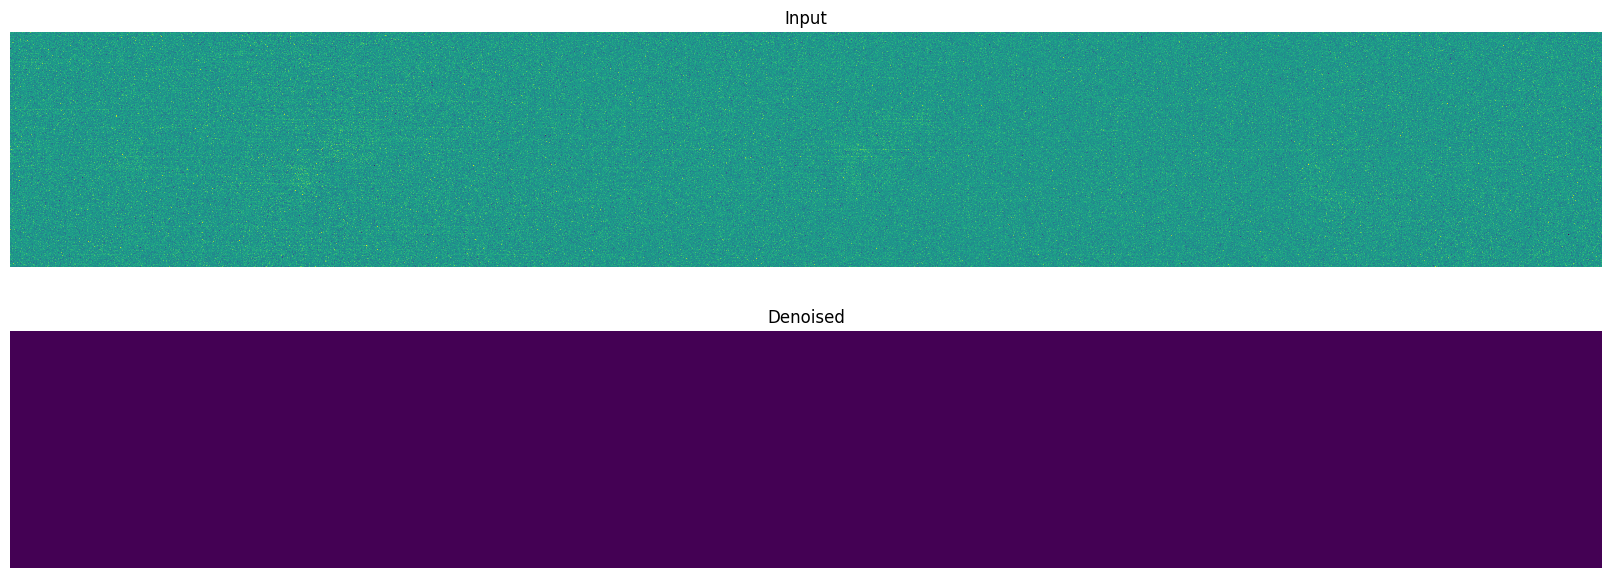

In [14]:
T = 7
Z = 449

input_image = inf_data_module.predict_dataset.input_extractor.image_stacks[0].extract_patch(
    sample_idx=T*511+Z,
    coords=(0, 0),
    patch_size=prediction.shape[-2:],
)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), constrained_layout=True)
axes[0].set_title("Input")
axes[1].set_title("Denoised")
axes[0].imshow(input_image[0, 1:-1, 1:-1], cmap="viridis", interpolation="nearest")
axes[1].imshow(prediction[T, 0, Z], cmap="viridis", interpolation="nearest")
for ax in axes.ravel():
    ax.axis("off")
plt.show()

## Train 3-D Model

In [ ]:
exp_dir = exp_base_dir / "n2v2_3d_10ep"

config = create_n2v_configuration(
    experiment_name="CustomerData_n2v2",
    data_type="czi",
    axes="SCZYX",
    patch_size=[64, 64, 64],
    batch_size=16,
    num_epochs=10,
    independent_channels=True,
    n_channels=1,
    use_n2v2=True,
    roi_size=11,
    masked_pixel_percentage=0.2,
    model_params={"use_batch_norm": False},
    optimizer_params={"lr": 1e-3},
    train_dataloader_params={"num_workers": 12},
    val_dataloader_params={"num_workers": 12},
    logger="tensorboard",
)

ng_data_config = _create_ng_data_configuration(
    data_type="custom",
    axes=config.data_config.axes,
    patch_size=config.data_config.patch_size,
    batch_size=config.data_config.batch_size,
    augmentations=list(config.data_config.transforms),
    patch_overlaps=None,
    train_dataloader_params=config.data_config.train_dataloader_params,
    val_dataloader_params=config.data_config.val_dataloader_params,
)

data_module = CareamicsDataModule(
    data_config=ng_data_config,
    train_data=[image_path],
    val_data=[image_path],
    pred_data=[image_path],
    image_stack_loader=lambda source, axes: create_czi_extractor(source, axes).image_stacks,
)

In [ ]:
model = N2VModule(config.algorithm_config)

In [ ]:
callbacks = [
    ModelCheckpoint(
        dirpath=exp_dir / "checkpoints",
        save_last=True,
        monitor="val_loss",
        mode="min",
        save_top_k=-1,
    ),
    LearningRateMonitor(logging_interval="step"),
]

trainer = Trainer(
    max_epochs=config.training_config.num_epochs,
    default_root_dir=exp_dir,
    devices=1,
    callbacks=callbacks,
)

In [ ]:
trainer.fit(model, data_module)

### Inference

In [ ]:
inference_config = NGDataConfig(
    data_type="custom",
    patching={
        "name": "tiled",
        "patch_size": [256, 128, 256],
        "overlaps": [32, 32, 32],
    },
    axes="ZYX",
    batch_size=1,
    image_means=data_module.train_dataset.input_stats.means,
    image_stds=data_module.train_dataset.input_stats.stds,
)

inf_data_module = CareamicsDataModule(
    data_config=inference_config,
    pred_data=[image_path],
    image_stack_loader=lambda source, axes: create_czi_extractor(source, axes).image_stacks,
)

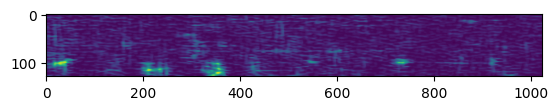

In [26]:
plt.imshow(predictions[0].data[0, 0, :, :])

In [ ]:
predictions = trainer.predict(model, datamodule=inf_data_module)
tile_infos = imageregions_to_tileinfos(predictions)
prediction = convert_outputs(tile_infos, tiled=True)
prediction = np.concatenate(prediction, axis=0)
prediction.shape

In [29]:
tile_infos = imageregions_to_tileinfos(predictions)


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (959,) + inhomogeneous part.

In [ ]:
prediction.min(), prediction.max()

In [ ]:
T = 7
Z = 449

input_image = inf_data_module.predict_dataset.input_extractor.image_stacks[0].extract_patch(
    sample_idx=T,
    coords=(Z, 0, 0),
    patch_size=(1,) + prediction.shape[-2:],
)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), constrained_layout=True)
axes[0].set_title("Input")
axes[1].set_title("Denoised")
axes[0].imshow(input_image[0, 0, 1:-1, 1:-1], cmap="viridis", interpolation="nearest")
axes[1].imshow(prediction[T, 0, Z, 1:-1, 1:-1], cmap="viridis", interpolation="nearest")
for ax in axes.ravel():
    ax.axis("off")
plt.show()